## **Problem Statement**

#### **What is the problem I am trying to solve?**

Human emotions play a very important role in understanding a person’s mental and emotional state.
In real life, emotions are not expressed only through words — they are strongly reflected through facial expressions.

The goal of this module is to detect the emotion of a user from a single facial image.

This CNN model is not the final product itself — it is a sub-module of a larger multimodal system called EmoNarrator, which combines:

- image understanding (CNN)

- contextual reasoning (LLM)

- voice narration (TTS)

This CNN model is responsible only for answering one question:


> What emotion is visible on the user’s face?



#### **Why this problem is important for my project**

The emotion predicted by this CNN model becomes the core signal that drives the rest of the system.

If emotion detection is wrong:

narration becomes meaningless

context reasoning becomes incorrect

the entire pipeline collapses

So emotion recognition must be:

- reliable

- generalisable

- unbiased

That’s why this module is built carefully and independently.

## **Understanding Real-World Dataset Structure**

**What I observed**

Unlike many tutorial datasets, the STEER / KDEF-style dataset does not contain:

train folder

test folder

validation folder

Instead, it looks like this:
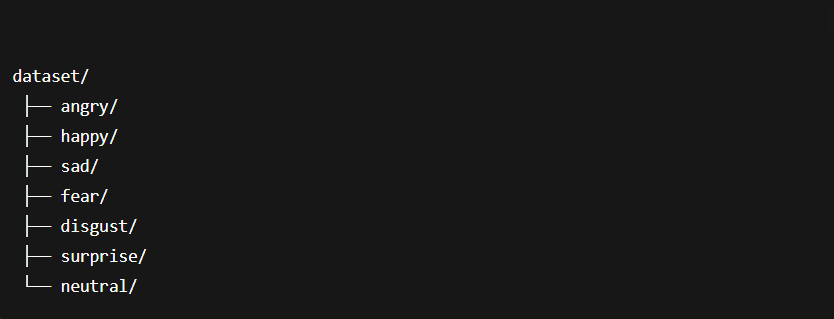

**Why this matters**

In real-world projects, data almost never comes pre-split.

Companies give:

- raw images

- raw labels

- no guidance

So before model building, I must:

- organise the data

- split it correctly

- avoid data leakage

This step improves:

- generalisation

- evaluation honesty

- model trustworthiness

## **Import Required Libraries**

In [ ]:
import os
import shutil
import random
import math
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight


## **Dataset Paths**

Defined the root dataset path and created references for train, validation, and test datasets.

In [ ]:
import zipfile

zip_path = "archive (8).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)


Dataset extracted to: /content/dataset


In [ ]:
os.listdir(extract_path)


['happy', 'angry', 'sad', 'fear', 'surprise', 'neutral', 'disgust']

In [ ]:
#Creating  Train / Validation / Test Structure
split_root = "/content/emotion_split"
os.makedirs(split_root, exist_ok=True)

for split in ["train", "valid", "test"]:
    os.makedirs(os.path.join(split_root, split), exist_ok=True)


### **Stratified Dataset Split**

In [ ]:
RANDOM_SEED = 42
train_ratio = 0.72
valid_ratio = 0.08
test_ratio  = 0.20

random.seed(RANDOM_SEED)

classes = os.listdir(extract_path)

for cls in classes:
    cls_path = os.path.join(extract_path, cls)
    images = [os.path.join(cls_path, f) for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    temp, test_imgs = train_test_split(
        images, test_size=test_ratio, random_state=RANDOM_SEED
    )

    valid_frac = valid_ratio / (train_ratio + valid_ratio)

    train_imgs, valid_imgs = train_test_split(
        temp, test_size=valid_frac, random_state=RANDOM_SEED
    )

    for split_name, file_list in [
        ("train", train_imgs),
        ("valid", valid_imgs),
        ("test", test_imgs)
    ]:
        dst = os.path.join(split_root, split_name, cls)
        os.makedirs(dst, exist_ok=True)

        for f in file_list:
            shutil.copy2(f, dst)


In [ ]:
root = "/content/KDEF_split"
train_dir = os.path.join(root, "train")
valid_dir = os.path.join(root, "valid")
test_dir  = os.path.join(root, "test")


**Why this step is necessary**

Separating datasets ensures:

- training data teaches

- validation data tunes

- test data judges

The test set is never touched during training — this gives honest performance estimation.

## **Hyperparameter Setup**

Define learning configuration in one place.

In [ ]:
IMG_SIZE = (260, 260)
BATCH_SIZE = 16
SEED = 42
NUM_CLASSES = 7


**Why I designed it this way**

- EfficientNetB2 expects 260×260 input

- batch size kept small due to hardware limitation

- fixed seed ensures reproducibility

- number of classes must match emotion categories

This reflects practical constraints, not theory.

### **Why I Chose EfficientNet**


Initially, I tried heavier models like ResNet.

But I faced:

- long training time

- laptop GPU limitations

- memory issues

EfficientNet was chosen because:

- fewer parameters

- better accuracy-per-computation

- suitable for limited hardware

- strong transfer learning capability

This decision was based on engineering reality, not popularity.

## **Image Preprocessing & Augmentation**

In [ ]:
from tensorflow.keras.applications.efficientnet import EfficientNetB2, preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


EfficientNet was trained on ImageNet.

If I don’t apply the same preprocessing:

- pretrained weights become meaningless

- transfer learning fails

Augmentation helps the model learn:

- slight pose variations

- real-world facial movement

- robustness

This improves generalisation significantly.

## **Data Generators**

In [ ]:
train_gen = train_datagen.flow_from_directory(
    os.path.join(split_root, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

valid_gen = val_datagen.flow_from_directory(
    os.path.join(split_root, "valid"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_datagen.flow_from_directory(
    os.path.join(split_root, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 2112 images belonging to 7 classes.
Found 238 images belonging to 7 classes.
Found 588 images belonging to 7 classes.


## **Build and train  CNN Model (EfficientNet)**

In [ ]:


# ---------- Build model ----------

base_model = EfficientNetB2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False  # freeze for initial training bcz primitive features of images are same

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
# if mixed precision is on, cast softmax to float32 to avoid numeric issues
if tf.keras.mixed_precision.global_policy().name == 'mixed_float16':
    x = layers.Dense(NUM_CLASSES)(x)
    outputs = layers.Activation('softmax', dtype='float32')(x)
else:
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

# ---------- Callbacks ----------
checkpoint_cb = callbacks.ModelCheckpoint("kdef_effb2_best.h5", save_best_only=True, monitor="val_accuracy", mode="max")
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
earlystp = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)

# ---------- Train head ----------
EPOCHS_HEAD = 8
history_head = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_HEAD,
    validation_data=valid_generator,
    validation_steps=validation_steps,
    class_weight=class_weights,
    callbacks=[checkpoint_cb, reduce_lr, earlystp]
)

# ---------- Fine-tune
base_model.trainable = True
total_layers = len(base_model.layers)
unfreeze_from = int(total_layers * 0.7)   # unfreeze top 30%
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= unfreeze_from)

model.compile(optimizer=optimizers.Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

EPOCHS_FINE = 6
history_fine = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_FINE,
    validation_data=valid_generator,
    validation_steps=validation_steps,
    class_weight=class_weights,
    callbacks=[checkpoint_cb, reduce_lr, earlystp]
)

# ---------- Save final model and show preview ----------
model.save("kdef_effb2_final.h5")
print("Saved model: kdef_effb2_final.h5")
print("Preview local file path (use as URL):", file_url)

# ---------- Quick eval on test set ----------
test_steps = math.ceil(test_generator.samples / BATCH_SIZE)
results = model.evaluate(test_generator, steps=test_steps)
print("Test results (loss, acc):", results)


preview file (local): /mnt/data/c8d81af8-54a7-4d09-9559-49ced847a521.png
Train counts per class: {'angry': 302, 'disgust': 302, 'fear': 302, 'happy': 302, 'neutral': 302, 'sad': 301, 'surprise': 301}
Class weights (should be ~1.0 for balanced KDEF): {0: 0.9990539262062441, 1: 0.9990539262062441, 2: 0.9990539262062441, 3: 0.9990539262062441, 4: 0.9990539262062441, 5: 1.0023730422401518, 6: 1.0023730422401518}
Mixed precision not enabled / not available: cannot import name 'experimental' from 'tensorflow.keras.mixed_precision' (/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/mixed_precision/__init__.py)
Found 2112 images belonging to 7 classes.
Found 238 images belonging to 7 classes.
Found 588 images belonging to 7 classes.
Train samples: 2112
Valid samples: 238
Test samples:  588
Steps/epoch: 132 Validation steps: 15
Class mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,495,616 (32.41 MB)

 Trainable params: 726,023 (2.77 MB)

...

132/132 ━━━━━━━━━━━━━━━━━━━━ 377s 3s/step - accuracy: 0.4919 - loss: 1.3032 - val_accuracy: 0.6429 - val_loss: 1.0092 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.
Epoch 1/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 597s 4s/step - accuracy: 0.4228 - loss: 1.7851 - val_accuracy: 0.6345 - val_loss: 1.1657 - learning_rate: 1.0000e-04
Epoch 2/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6588 - loss: 0.9589

132/132 ━━━━━━━━━━━━━━━━━━━━ 563s 4s/step - accuracy: 0.6590 - loss: 0.9584 - val_accuracy: 0.6933 - val_loss: 0.8630 - learning_rate: 1.0000e-04
Epoch 3/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7403 - loss: 0.6951

132/132 ━━━━━━━━━━━━━━━━━━━━ 567s 4s/step - accuracy: 0.7405 - loss: 0.6949 - val_accuracy: 0.8067 - val_loss: 0.5593 - learning_rate: 1.0000e-04
Epoch 4/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 626s 4s/step - accuracy: 0.8080 - loss: 0.5128 - val_accuracy: 0.7773 - val_loss: 0.6525 - learning_rate: 1.0000e-04
Epoch 5/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8557 - loss: 0.4177

132/132 ━━━━━━━━━━━━━━━━━━━━ 570s 4s/step - accuracy: 0.8557 - loss: 0.4178 - val_accuracy: 0.8613 - val_loss: 0.4131 - learning_rate: 1.0000e-04
Epoch 6/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 625s 4s/step - accuracy: 0.8788 - loss: 0.3641 - val_accuracy: 0.8319 - val_loss: 0.4393 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 5.


Saved model: kdef_effb2_final.h5
Preview local file path (use as URL): /mnt/data/c8d81af8-54a7-4d09-9559-49ced847a521.png
37/37 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8823 - loss: 0.3293
Test results (loss, acc): [0.31430643796920776, 0.884353756904602]


## **Learning Curve Visualisation**

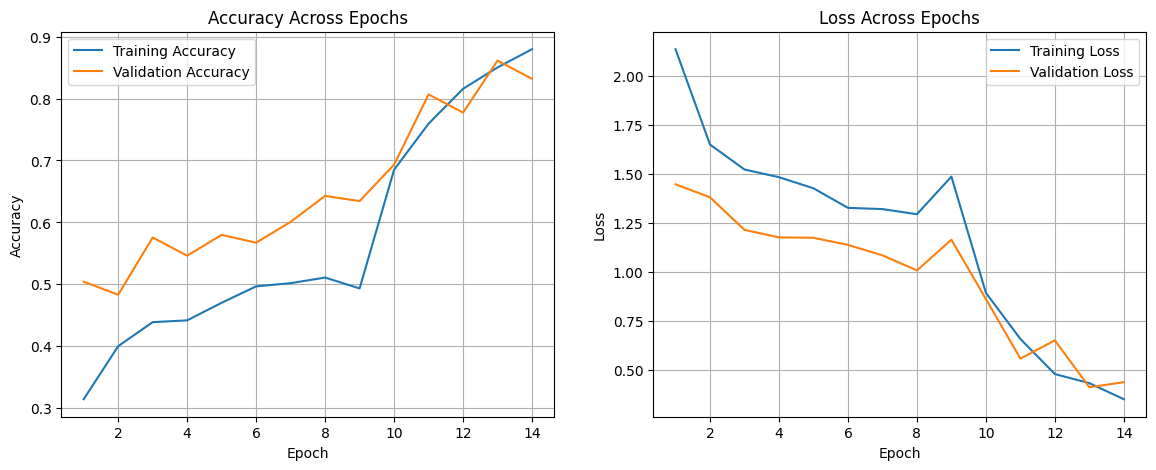

In [ ]:
import matplotlib.pyplot as plt

# Replace these with your actual history objects
hist1 = history_head       # phase 1 training history
hist2 = history_fine    # phase 2 fine-tuning history

# Merge both
acc     = hist1.history['accuracy']     + hist2.history['accuracy']
val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']

loss     = hist1.history['loss']     + hist2.history['loss']
val_loss = hist1.history['val_loss'] + hist2.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

# ---- Accuracy ----
plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title("Accuracy Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# ---- Loss ----
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title("Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
# after training
model.save('emotional_narrator_CNN_part1.keras')   # preferred modern format


## **Testing on Sample image**

#### **Load pretrained model safely**

In [ ]:
from tensorflow import keras

MODEL_PATH = "/emotional_narrator_CNN_part1.keras"

def load_model_safe(path):
    # load without optimizer to avoid warnings
    return keras.models.load_model(path, compile=False)

model = load_model_safe(MODEL_PATH)
print("✅ Model loaded successfully")


✅ Model loaded successfully


In [ ]:
#emotion labels
CLASS_NAMES = ['angry','disgust','fear','happy','neutral','sad','surprise']



#### **Prediction + Visualization Function**

In [ ]:
def smart_fusion(original, face_probs):
    """
    Human-aware fusion strategy
    """

    orig_neutral = original[CLASS_NAMES.index("neutral")]
    face_neutral = face_probs[CLASS_NAMES.index("neutral")]

    orig_top = CLASS_NAMES[np.argmax(original)]
    face_top = CLASS_NAMES[np.argmax(face_probs)]

    # CASE 1: original image strongly neutral → trust original
    if orig_neutral > 0.60:
        fused = original
        reason = "strong neutral in original image"

    # CASE 2: face crop extremely confident (real emotion)
    elif np.max(face_probs) > 0.75:
        fused = face_probs
        reason = "strong facial emotion detected"

    # CASE 3: mixed signals → average
    else:
        fused = 0.5 * original + 0.5 * face_probs
        fused = fused / fused.sum()
        reason = "balanced fusion"

    return fused, reason


In [ ]:
def predict_emotion_from_image_fixed(model, image_path, tta=True):

    pil = Image.open(image_path)
    pil_rgb = composite_alpha_to_rgb(pil)

    # ORIGINAL
    x_full = preprocess_for_model(pil_rgb)
    out_full = model.predict(x_full)[0]
    probs_full = softmax_if_needed(out_full)

    # FACE
    face = detect_largest_face_cv(pil_rgb)
    if face is None:
        w,h = pil_rgb.size
        side = min(w,h)
        face = pil_rgb.crop(((w-side)//2, (h-side)//2,
                              (w+side)//2, (h+side)//2))

    x_face = preprocess_for_model(face)
    out_face = model.predict(x_face)[0]
    probs_face = softmax_if_needed(out_face)

    # TTA
    if tta:
        face_mirror = face.transpose(Image.FLIP_LEFT_RIGHT)
        out_m = model.predict(preprocess_for_model(face_mirror))[0]
        probs_m = softmax_if_needed(out_m)
        face_probs = (probs_face + probs_m) / 2.0
    else:
        face_probs = probs_face

    # 🔥 SMART FUSION
    fused, reason = smart_fusion(probs_full, face_probs)

    best_idx = int(np.argmax(fused))

    return {
        "final_emotion": CLASS_NAMES[best_idx],
        "confidence": float(fused[best_idx]),
        "fusion_reason": reason,
        "probs": {CLASS_NAMES[i]: float(fused[i]) for i in range(len(CLASS_NAMES))},
        "original": probs_full,
        "face": face_probs
    }


#### **Test on image**

In [ ]:
import numpy as np
import cv2
from PIL import Image, ImageOps
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.efficientnet import preprocess_input

CLASS_NAMES = ['angry','disgust','fear','happy','neutral','sad','surprise']

def load_model_safe(path):
    # load without optimizer state to silence optimizer mismatch warnings
    path='/content/emotional_narrator_CNN_part1.keras'
    return keras.models.load_model(path, compile=False)

def composite_alpha_to_rgb(pil):
    # if PNG has alpha, composite on white background
    if pil.mode == "RGBA":
        bg = Image.new("RGB", pil.size, (255,255,255))
        bg.paste(pil, mask=pil.split()[3])
        return bg
    return pil.convert("RGB")

def detect_largest_face_cv(pil_img):
    # returns PIL Image of face crop or None
    arr = np.array(pil_img)[:,:,::-1]  # RGB->BGR
    gray = cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)
    if len(faces) == 0:
        return None
    faces = sorted(faces, key=lambda r: r[2]*r[3], reverse=True)
    x,y,w,h = faces[0]
    crop = arr[y:y+h, x:x+w][:,:,::-1]  # back to RGB
    return Image.fromarray(crop)

def preprocess_for_model(pil_img, input_size=(260,260)):
    img = ImageOps.fit(pil_img, input_size, Image.BICUBIC)
    arr = np.asarray(img).astype('float32')
    arr = preprocess_input(arr)   # EfficientNet preprocess
    return np.expand_dims(arr, axis=0)

def softmax_if_needed(logits):
    arr = np.asarray(logits, dtype=float)
    if np.all(arr >= 0) and np.isclose(arr.sum(), 1.0, atol=1e-3):
        return arr
    import tensorflow as tf
    return tf.nn.softmax(arr).numpy()

def predict_emotion_from_image(model, image_path, tta=True):
    """
    Robust prediction pipeline:
      - open image, composite alpha if needed
      - try face detection and crop; fallback to center-crop
      - generate predictions for:
         * original full-res pass
         * face crop
         * TTA: mirror of face crop
      - average probabilities intelligently and return top-k
    Returns: dict { 'best_label', 'best_conf', 'probs', 'all_variants': {...} }
    """
    pil = Image.open(image_path)
    pil_rgb = composite_alpha_to_rgb(pil)
    results = {}

    # Variant A: original resized image
    x_full = preprocess_for_model(pil_rgb)
    out_full = model.predict(x_full)[0]
    probs_full = softmax_if_needed(out_full)
    results['original'] = probs_full

    # Variant B: face crop (cv)
    face = detect_largest_face_cv(pil_rgb)
    if face is None:
        # fallback: center square crop
        w,h = pil_rgb.size
        side = min(w,h)
        face = pil_rgb.crop(((w-side)//2, (h-side)//2, (w+side)//2, (h+side)//2))
    x_face = preprocess_for_model(face)
    out_face = model.predict(x_face)[0]
    probs_face = softmax_if_needed(out_face)
    results['face'] = probs_face

    # Variant C: TTA mirror of face (optional)
    if tta:
        face_mirror = face.transpose(Image.FLIP_LEFT_RIGHT)
        out_m = model.predict(preprocess_for_model(face_mirror))[0]
        probs_m = softmax_if_needed(out_m)
        results['face_mirror'] = probs_m

        # combine face + mirror (simple average)
        combined_face = (probs_face + probs_m) / 2.0
        results['face_tta_avg'] = combined_face
    else:
        combined_face = probs_face

    # Fuse strategy: give more weight to face crops (since training used cropped faces)
    # Weighted average: 0.2 * original + 0.8 * combined_face
    fused = 0.1 * results['original'] + 0.9 * combined_face
    fused = fused / fused.sum()

    best_idx = int(np.argmax(fused))
    return {
        'best_label': CLASS_NAMES[best_idx],
        'best_index': best_idx,
        'best_conf': float(fused[best_idx]),
        'probs': {CLASS_NAMES[i]: float(fused[i]) for i in range(len(CLASS_NAMES))},
        'variants': {k: {CLASS_NAMES[i]: float(results[k][i]) for i in range(len(CLASS_NAMES))} for k in results}
    }


In [ ]:
import matplotlib.pyplot as plt

def show_emotion_on_image(image_path, probs_dict):
    """
    Shows image with emotion probabilities written on top
    """

    img = Image.open(image_path).convert("RGB")

    # sort probs high → low
    probs_sorted = dict(
        sorted(probs_dict.items(), key=lambda x: x[1], reverse=True)
    )

    plt.figure(figsize=(5,7))
    plt.imshow(img)
    plt.axis("off")

    y = 0.95
    for emotion, prob in probs_sorted.items():
        plt.text(
            0.02, y,
            f"{emotion}: {prob*100:.1f}%",
            transform=plt.gca().transAxes,
            fontsize=12,
            color="white",
            bbox=dict(facecolor="black", alpha=0.7)
        )
        y -= 0.07

    plt.show()


In [ ]:
#uploading image
uploaded = files.upload()

# Get image path automatically
image_path = list(uploaded.keys())[0]
image_path = os.path.join("/content", image_path)

print("✅ Image uploaded at:", image_path)

Saving 26_31.jpg to 26_31.jpg
✅ Image uploaded at: /content/26_31.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Predicted emotion: angry
Confidence: 0.5189866157258929


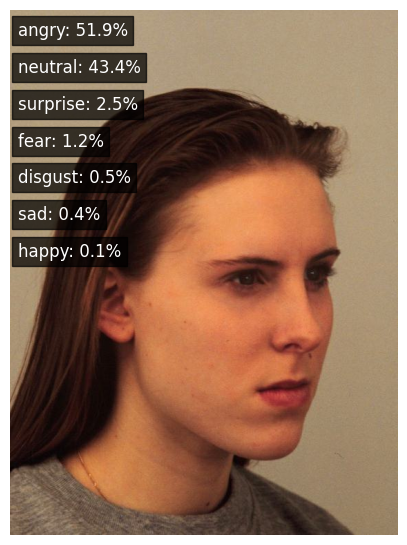

In [ ]:
model = load_model_safe("/emotional_narrator_CNN_part1.keras")

res = predict_emotion_from_image(
    model,
    image_path,
    tta=True
)

print("Predicted emotion:", res["best_label"])
print("Confidence:", res["best_conf"])

# 🔥 THIS LINE SHOWS PROBABILITIES ON IMAGE
show_emotion_on_image(
    image_path,
    res["probs"]
)
